In [2]:
import tensorflow as tf
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices: tf.config.experimental.set_memory_growth(device, True)


In [1]:

import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, GlobalAveragePooling2D, Dense
from keras.layers import BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from PIL import Image, ImageChops, ImageEnhance
from tqdm.notebook import tqdm

# VGG16 imports
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [3]:
def convert_to_cea_image(path, qualities=[95, 90, 85, 80, 75]):
    original = Image.open(path).convert("RGB")

    cea_maps = []

    for q in qualities:
        temp_path = f"temp_cea_{q}.jpg"
        original.save(temp_path, "JPEG", quality=q)
        compressed = Image.open(temp_path)

        diff = ImageChops.difference(original, compressed)

        # Normalize (VERY IMPORTANT)
        extrema = diff.getextrema()
        max_diff = max(e[1] for e in extrema) or 1
        scale = 255.0 / max_diff
        diff = ImageEnhance.Brightness(diff).enhance(scale)

        cea_maps.append(np.array(diff))

    # Average all CEA maps
    cea_image = np.mean(cea_maps, axis=0)

    return cea_image


In [4]:
#Dataset preparation
def prepare_image(image_path):
    image_size = (128, 128)

    cea_image = convert_to_cea_image(image_path)
    cea_image = Image.fromarray(cea_image.astype(np.uint8))
    cea_image = cea_image.resize(image_size)

    return np.array(cea_image) / 255.0

     #normalizing the array values obtained from input image

In [5]:
X = [] # CEA converted images
Y = [] # 0 for fake, 1 for real

In [6]:
#adding authentic images

path = 'dataset/real'       #folder path of the authentic images in the dataset
for filename in tqdm(os.listdir(path),desc="Processing Images : "):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        full_path = os.path.join(path, filename)
        X.append(prepare_image(full_path))        
        Y.append(1)     # label for authentic images 
        

Processing Images :   0%|          | 0/7492 [00:00<?, ?it/s]

In [7]:
#adding forged images

path = 'dataset/forged'       #folder path of the forged images in the dataset
for filename in tqdm(os.listdir(path),desc="Processing Images : "):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        full_path = os.path.join(path, filename)
        X.append(prepare_image(full_path))        
        Y.append(0)     # label for forged images 
        


Processing Images :   0%|          | 0/5123 [00:00<?, ?it/s]

In [8]:
# Dataset Integrity Check
print("Images loaded:", len(X))
print("Labels loaded:", len(Y))

Images loaded: 9501
Labels loaded: 9501


In [9]:
# Convert to NumPy + Shuffle
X = np.array(X)
Y = np.array(Y)

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
Y = Y[indices]

# Dataset formatting & class distribution

# (ONLY reshape if prepare_image did NOT reshape already)
X = X.reshape(-1, 128, 128, 3)

unique, counts = np.unique(Y, return_counts=True)
print("Dataset distribution:", dict(zip(unique, counts)))

Dataset distribution: {np.int64(0): np.int64(2064), np.int64(1): np.int64(7437)}


In [10]:
#partitioning datsaset for training,validation and testing

# Training : Validation : Testing = 76 : 19 : 5
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size = 0.05, random_state=5)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size = 0.2, random_state=5)

print(f'Training images: {len(X_train)} , Training labels: {len(Y_train)}')
print(f'Validation images: {len(X_val)} , Validation labels: {len(Y_val)}')
print(f'Test images: {len(X_test)} , Test labels: {len(Y_test)}')

Training images: 7220 , Training labels: 7220
Validation images: 1805 , Validation labels: 1805
Test images: 476 , Test labels: 476


In [11]:
#data agumentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(2.2906091370558377), 1: np.float64(0.6396172927002126)}


In [13]:

# model architecture
def build_model():
    model = Sequential()

    model.add(Conv2D(64, (5,5), activation='relu', input_shape=(128,128,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (5,5), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (5,5), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (5,5), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (5,5), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (5,5), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(32, (5,5), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D((2,2)))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='sigmoid'))

    return model


In [16]:
model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 124, 124, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 120, 120, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 32)       │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 570,113 (2.17 MB)

 Trainable params: 569,281 (2.17 MB)

 Non-trainable params: 832 (3.25 KB)

In [17]:
#model training

epochs = 35
batch_size = 32


In [18]:
#optimizer
init_lr = 1e-5  # learning rate

optimizer = Adam(learning_rate=init_lr)


#model training and complie
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [19]:
#Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)


In [20]:
hist = model.fit(
    datagen.flow(X_train, Y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping],
    class_weight=class_weights
)

Epoch 1/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 688s 3s/step - accuracy: 0.7496 - loss: 0.5970 - val_accuracy: 0.2139 - val_loss: 1.1874
Epoch 2/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 729s 3s/step - accuracy: 0.7612 - loss: 0.4902 - val_accuracy: 0.2139 - val_loss: 1.9152
Epoch 3/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 713s 3s/step - accuracy: 0.7711 - loss: 0.4666 - val_accuracy: 0.5274 - val_loss: 0.7705
Epoch 4/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 722s 3s/step - accuracy: 0.7752 - loss: 0.4535 - val_accuracy: 0.8321 - val_loss: 0.3495
Epoch 5/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 701s 3s/step - accuracy: 0.7880 - loss: 0.4450 - val_accuracy: 0.8388 - val_loss: 0.3326
Epoch 6/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 768s 3s/step - accuracy: 0.7878 - loss: 0.4330 - val_accuracy: 0.8377 - val_loss: 0.3311
Epoch 7/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 705s 3s/step - accuracy: 0.7974 - loss: 0.4256 - val_accuracy: 0.8388 - val_loss: 0.3475
Epoch 8/35
226/226 ━━━━━━━━━━━━━━━━━━━━ 784s 3s/step - accuracy: 0.8040 - loss: 0.4085 - val_accu

In [21]:
# Save the trained model
model.save('training_model.h5')

# Get training history
history_dict = hist.history

# Save training history as JSON
import json
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f)

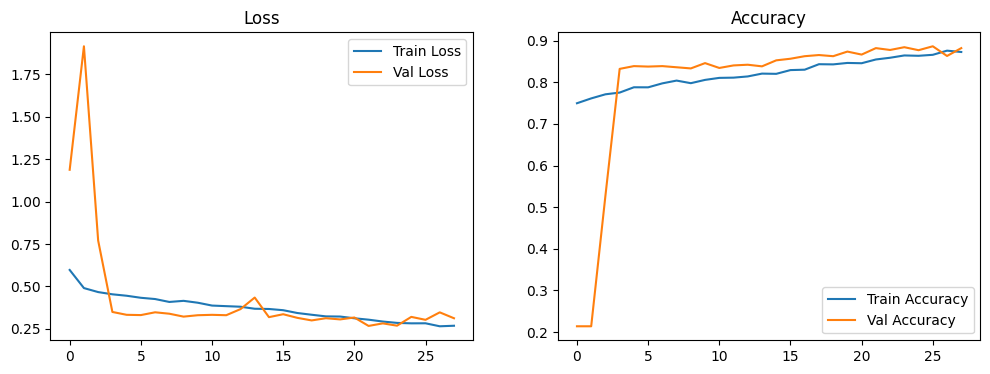

In [22]:
#plotting and training curve

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()



In [23]:
# ---- STANDARD TEST ACCURACY (Keras default threshold = 0.5) ----
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print("Test Accuracy (model.evaluate):", acc * 100)


Test Accuracy (model.evaluate): 88.02521228790283


In [24]:
#confusion matrix
def plot_confusion_matrix(cf_matrix):
  
    group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()] #number of images in each classification block
    group_percentages = ["{0:.2%}".format(value) for value in cf_matrix.flatten()/np.sum(cf_matrix)] #percentage value of images in each block w.r.t total images

    axes_labels=['Forged', 'Authentic']
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cf_matrix, annot=labels, fmt='',cmap="flare" , xticklabels=axes_labels, yticklabels=axes_labels)

    plot_xlabel = plt.xlabel('Predicted labels', fontsize = 13)
    plot_ylabel = plt.ylabel('True labels', fontsize = 13)
    plot_title = plt.title('Confusion Matrix', fontsize= 10,fontweight='bold')

57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 577ms/step


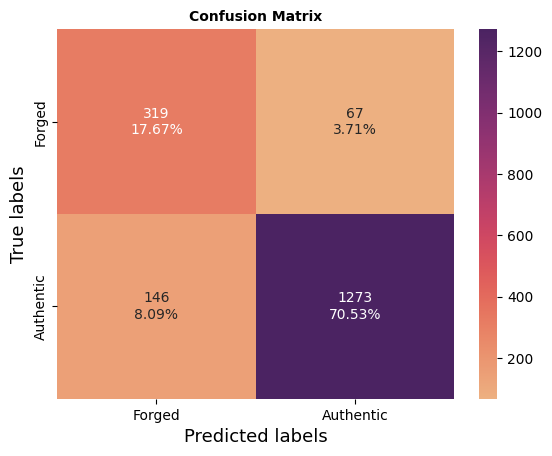

In [25]:
THRESHOLD = 0.5

Y_pred = model.predict(X_val)
Y_pred_classes = (Y_pred >= THRESHOLD).astype(int)
Y_true = Y_val                             

confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)     # compute the confusion matrix
plot_confusion_matrix(confusion_mtx)                         # plot the confusion matrix


In [26]:
#classification report
y_test_probs = model.predict(X_test)
Y_test_pred = (y_test_probs >= THRESHOLD).astype(int)

print("Test Classification Report")
print(classification_report(Y_test, Y_test_pred, target_names=['Forged','Authentic']))


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 570ms/step
Test Classification Report
              precision    recall  f1-score   support

      Forged       0.67      0.86      0.76       102
   Authentic       0.96      0.89      0.92       374

    accuracy                           0.88       476
   macro avg       0.82      0.87      0.84       476
weighted avg       0.90      0.88      0.89       476



In [27]:
#testing accuracy
class_names = ['Forged', 'Authentic']

In [28]:
y_test_probs = model.predict(X_test)
auc_score = roc_auc_score(Y_test, y_test_probs)
print("ROC-AUC Score:", auc_score)

15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 549ms/step
ROC-AUC Score: 0.9442434727901856


In [29]:
#training of VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=base_model.input, outputs=output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


In [30]:
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
history_vgg = vgg_model.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    epochs=20,
    validation_data=(X_val, Y_val),
    class_weight=class_weights
)

Epoch 1/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 459s 2s/step - accuracy: 0.2299 - loss: 0.6960 - val_accuracy: 0.2942 - val_loss: 0.7071
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.5024 - loss: 0.6856 - val_accuracy: 0.6981 - val_loss: 0.6790
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.7051 - loss: 0.6805 - val_accuracy: 0.6266 - val_loss: 0.6812
Epoch 4/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.6389 - loss: 0.6761 - val_accuracy: 0.7319 - val_loss: 0.6673
Epoch 5/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.6814 - loss: 0.6716 - val_accuracy: 0.7518 - val_loss: 0.6590
Epoch 6/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - accuracy: 0.6891 - loss: 0.6671 - val_accuracy: 0.7546 - val_loss: 0.6530
Epoch 7/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.6783 - loss: 0.6631 - val_accuracy: 0.7623 - val_loss: 0.6450
Epoch 8/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 466s 2s/step - accuracy: 0.7087 - loss: 0.6593 - val_accu

In [32]:
loss_vgg, acc_vgg = vgg_model.evaluate(X_test, Y_test)

print("CNN Accuracy:", acc * 100)
print("VGG16 Accuracy:", acc_vgg * 100)

15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7647 - loss: 0.5912
CNN Accuracy: 88.02521228790283
VGG16 Accuracy: 76.47058963775635
